# **Mối quan hệ giữa sức khỏe tâm thần và các yếu tố kinh tế xã hội, nhân khẩu học và môi trường trong thời gian phong tỏa COVID-19 — Phân tích hồi quy đa biến** #



## **Báo cáo Tiền Xử Lý Dữ Liệu — Yếu Tố Môi Trường & Sức Khỏe Tâm Thần (Tái lập từ MDPI)**

**Mục tiêu.** Tái xây dựng tập dữ liệu và các biến được sử dụng trong bài báo MDPI
*“Relationship between Mental Health and Socio-Economic, Demographic and Environmental Factors in the COVID-19 Lockdown Period—A Multivariate Regression Analysis”*
nhằm chuẩn bị bảng dữ liệu sạch cho việc ước lượng bằng **HMC/NUTS** (thực hiện ở phần sau).

Notebook này thực hiện các bước sau:

1. **Nạp dữ liệu** (xử lý linh hoạt các loại mã hóa và dấu phân cách — do dữ liệu OSF thường là TSV/latin-1).
2. **Lọc dữ liệu theo tiêu chí hợp lệ** (chỉ giữ lại những người tham gia đã đồng ý cung cấp dữ liệu – informed consent).
3. **Chuyển kiểu dữ liệu và xử lý giá trị thiếu** (chuyển sang số, loại bỏ các dòng thiếu cần thiết).
4. **Xây dựng 4 thang đo kết quả**:

   * Depression (Trầm cảm)
   * Unworthiness (Cảm giác vô giá trị)
   * Alienation (Xa lánh)
   * Helplessness (Bất lực)
     Mỗi thang gồm 5 câu hỏi Likert 1–7.
5. **Chuẩn hóa (z-score)** các biến liên tục nhằm ổn định thuật toán HMC.
6. **Chẩn đoán sơ bộ** và lưu lại file CSV cuối cùng để sử dụng cho mô hình HMC/NUTS.


## 1. Nạp dữ liệu

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt


In [2]:
from google.colab import files

uploaded = files.upload()
csv_path = list(uploaded.keys())[0]

print("File đã upload:", csv_path)

Saving Dataset.csv to Dataset.csv
File đã upload: Dataset.csv


In [3]:
import pandas as pd

df_raw = pd.read_csv("Dataset.csv", encoding='latin1', sep='\t')
df_raw.head()

,IDnumber,StartDate,EndDate,LocationLatitude,LocationLongitude,InformedConsent,OfflineContact_Closeness_1,OfflineContact_Initials_1,OfflineContact_Closeness_2,OfflineContact_Initials_2,...,Infected_Country,Infected_ProvReg,Infected_ProvCountry,Infected_RegCountry,LevelOfContagion,SocialIsolation,OfflineSocialContacts_Filter,OfflineSocialContacts_Scoring,OnlineSocialContacts_Filter,OnlineSocialContacts_Scoring
0,1,03/12/2020 15:35,03/12/2020 15:38,,,1,,,,,...,14568,,,,,4,1,0,1,0
1,2,03/12/2020 16:13,03/12/2020 16:32,45.47070313,9.188903809,1,5,AV,3,GB,...,14568,"134,982,332,155,477","78,665,568,369,028","582,784,184,514,003",1,4,1,8,1,18
2,3,03/12/2020 16:46,03/12/2020 16:52,44.62860107,10.61019897,1,2,b,4,g,...,14568,"631,741,140,215,717",",844316309719934","133,649,093,904,448",0,4,1,10,1,3
3,4,03/12/2020 16:49,3/17/2020 8:41:11,45.61399841,9.197601318,1,5,G,5,L,...,24053,"25,356,699,751,861","135,949,777,574,523","536,149,336,881,054",1,7,1,10,1,26
4,5,03/12/2020 16:54,03/12/2020 17:01,,,1,,,,,...,14568,,,,,4,,,,



### Lọc dữ liệu theo tiêu chí hợp lệ (tuân thủ đạo đức nghiên cứu)

Chúng tôi chỉ giữ lại những người tham gia **đã cung cấp sự đồng ý tham gia nghiên cứu (informed consent)**.
Trong bộ dữ liệu, biến `InformedConsent` có các giá trị:

* **"1" — đã đồng ý** → **giữ lại**
* **"2" hoặc để trống — không đồng ý hoặc không hợp lệ** → **loại bỏ**

Bài báo gốc cũng thực hiện thu hẹp mẫu cuối cùng dựa trên mức độ hoàn thành khảo sát và chất lượng dữ liệu có thể sử dụng.
Trong nghiên cứu này, chúng tôi sẽ áp dụng thêm **loại bỏ listwise (listwise deletion)** cho tất cả các biến được đưa vào mô hình ở bước sau (theo giả định **MCAR** giống như trong bài báo).



In [4]:
df = df_raw.copy()
if "InformedConsent" in df.columns:
    before = len(df)
    df["InformedConsent"] = pd.to_numeric(df["InformedConsent"], errors="coerce")
    df = df[df["InformedConsent"] == 1]
    after = len(df)
    print(f"Kept consented participants: {after}/{before} ({after/before:.1%})")
else:
    print("Warning: 'InformedConsent' not found; proceeding without consent filtering.")
df.shape


Kept consented participants: 2120/2470 (85.8%)


(2120, 100)

## 3. Các biến được sử dụng để tái lập mô hình

### **Biến kết quả (Outcomes)**

(Mỗi thang đo được tính bằng **trung bình của 5 câu hỏi**, thang Likert 1–7):

* **`Depression` (Trầm cảm)**: câu 1–5
* **`Unworthiness` (Cảm giác vô giá trị)**: câu 6–10

  * **sử dụng các biến `_recode` cho câu 6, 8, 9 (nếu có)**
* **`Alienation` (Xa lánh)**: câu 11–15
* **`Helplessness` (Bất lực)**: câu 16–20

  * **sử dụng `_recode` cho câu 18, 19**
  * **không đảo chiều mục số 16** (theo hướng dẫn của bài báo)

---

### **Biến dự đoán (Predictors)**

(giống như trong bài báo gốc)

* **Yếu tố về không gian sống (Space Adequacy):**

  * `SpaceAdequacy_Size` — mức độ rộng
  * `SpaceAdequacy_Brightness` — mức độ sáng
  * `SpaceAdequacy_Privacy` — mức độ riêng tư

* **Yếu tố nhân khẩu – xã hội (Demographic/Socio-economic):**

  * `Gender` (1 = nam, 0 = nữ)
  * `Age` (tuổi)
  * `Employed` (tình trạng việc làm, 0/1)
  * `HigherEducation` (trình độ học vấn cao, 0/1)
  * `SocialIsolation` (số ngày giãn cách xã hội; 4–20 ngày)

---

### **Trong bước tiền xử lý:**

1. Chuyển tất cả các biến trên sang dạng số (**numeric**) khi cần
   (`errors = 'coerce'` để xử lý lỗi chuyển đổi).
2. Loại bỏ các dòng có dữ liệu thiếu trên bất kỳ biến nào thuộc mô hình
   (**listwise deletion**).



In [5]:
import pandas as pd
import numpy as np

# ===== A) TÍNH CONTACT =====
off_cols = [f"OfflineContact_Closeness_{i}" for i in range(1, 11)]
on_cols  = [f"OnlineContact_Closeness_{i}"  for i in range(1, 11)]

df[off_cols] = df[off_cols].apply(pd.to_numeric, errors="coerce")
df[on_cols]  = df[on_cols ].apply(pd.to_numeric, errors="coerce")

off_valid = df[off_cols].notna().sum(axis=1)
on_valid  = df[on_cols ].notna().sum(axis=1)

df["NumberOfContacts"] = off_valid + on_valid
df["ProportionOfflineContacts"] = (
    off_valid / (off_valid + on_valid)
).replace([np.inf, -np.inf], np.nan)

df["OfflineContacts_Closeness"] = df[off_cols].mean(axis=1)
df["OnlineContacts_Closeness"]  = df[on_cols ].mean(axis=1)

# ===== B) TẠO 4 BIẾN TÂM LÝ – SỬ DỤNG 5/5 ITEM =====
def m(i): return f"MentalHealthIssues_{i}"
def r(i): return f"MentalHealthIssues_{i}_recode"

y_items = {
    "Depression":   [m(1), m(2), m(3), m(4), m(5)],
    "Unworthiness": [r(6), m(7), r(8), r(9), m(10)],
    "Alienation":   [m(11), m(12), m(13), m(14), m(15)],
    "Helplessness": [m(16), m(17), r(18), r(19), m(20)],
}

for y, cols in y_items.items():
    df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")
    df[y] = df[cols].mean(axis=1)

# ===== C) DANH SÁCH PREDICTORS =====
predictors = [
    "SpaceAdequacy_Size","SpaceAdequacy_Brightness","SpaceAdequacy_Privacy",
    "Gender","Age","Occup","Educ",
    "SocialIsolation","NumberOfContacts","ProportionOfflineContacts",
    "OfflineContacts_Closeness","OnlineContacts_Closeness",
    "Infected_ProvReg","Infected_RegCountry","Infected_ProvCountry",
]

targets = list(y_items.keys())

# ===== D) LISTWISE DELETION (NHƯ BÀI BÁO) =====
df_model = df.dropna(subset=predictors + targets).copy()

print("Original:", df.shape)
print("After listwise deletion:", df_model.shape)


Original: (2120, 108)
After listwise deletion: (1327, 108)


In [6]:
df_model.head()

,IDnumber,StartDate,EndDate,LocationLatitude,LocationLongitude,InformedConsent,OfflineContact_Closeness_1,OfflineContact_Initials_1,OfflineContact_Closeness_2,OfflineContact_Initials_2,...,OnlineSocialContacts_Filter,OnlineSocialContacts_Scoring,NumberOfContacts,ProportionOfflineContacts,OfflineContacts_Closeness,OnlineContacts_Closeness,Depression,Unworthiness,Alienation,Helplessness
1,2,03/12/2020 16:13,03/12/2020 16:32,45.47070313,9.188903809,1.0,5.0,AV,3.0,GB,...,1,18,8,0.250000,4.0,3.000000,1.4,2.4,2.4,1.4
2,3,03/12/2020 16:46,03/12/2020 16:52,44.62860107,10.61019897,1.0,2.0,b,4.0,g,...,1,3,6,0.666667,2.5,1.500000,2.4,3.8,4.2,4.2
3,4,03/12/2020 16:49,3/17/2020 8:41:11,45.61399841,9.197601318,1.0,5.0,G,5.0,L,...,1,26,8,0.250000,5.0,4.333333,3.6,4.8,4.0,5.8
5,6,03/12/2020 17:11,03/12/2020 17:26,43.14790344,12.10969543,1.0,2.0,MF,3.0,NM,...,0,5,3,0.666667,2.5,5.000000,1.0,1.4,1.0,2.2
6,7,03/12/2020 17:11,03/12/2020 17:43,45.6697998,8.859893799,1.0,5.0,R,3.0,A,...,1,31,20,0.500000,1.8,3.100000,2.6,2.8,2.0,3.0


## 4. Xử lí bộ dữ liệu hiện tại

In [7]:
import pandas as pd
import numpy as np

# ===== A) TÍNH CONTACT =====
off_cols = [f"OfflineContact_Closeness_{i}" for i in range(1, 11)]
on_cols  = [f"OnlineContact_Closeness_{i}"  for i in range(1, 11)]

df[off_cols] = df[off_cols].apply(pd.to_numeric, errors="coerce")
df[on_cols]  = df[on_cols ].apply(pd.to_numeric, errors="coerce")

off_valid = df[off_cols].notna().sum(axis=1)
on_valid  = df[on_cols ].notna().sum(axis=1)

df["NumberOfContacts"] = off_valid + on_valid
df["ProportionOfflineContacts"] = (
    off_valid / (off_valid + on_valid)
).replace([np.inf, -np.inf], np.nan)

df["OfflineContacts_Closeness"] = df[off_cols].mean(axis=1)
df["OnlineContacts_Closeness"]  = df[on_cols ].mean(axis=1)

# ===== B) TẠO 4 BIẾN TÂM LÝ – SỬ DỤNG 5/5 ITEM =====
def m(i): return f"MentalHealthIssues_{i}"
def r(i): return f"MentalHealthIssues_{i}_recode"

y_items = {
    "Depression":   [m(1), m(2), m(3), m(4), m(5)],
    "Unworthiness": [r(6), m(7), r(8), r(9), m(10)],
    "Alienation":   [m(11), m(12), m(13), m(14), m(15)],
    "Helplessness": [m(16), m(17), r(18), r(19), m(20)],
}

for y, cols in y_items.items():
    df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")
    df[y] = df[cols].mean(axis=1)

# ===== C) DANH SÁCH PREDICTORS =====
predictors = [
    "SpaceAdequacy_Size","SpaceAdequacy_Brightness","SpaceAdequacy_Privacy",
    "Gender","Age","Occup","Educ",
    "SocialIsolation","NumberOfContacts","ProportionOfflineContacts",
    "OfflineContacts_Closeness","OnlineContacts_Closeness",
    "Infected_ProvReg","Infected_RegCountry","Infected_ProvCountry",
]

targets = list(y_items.keys())

for name, cols in y_items.items():
    tmp = df_model[cols].apply(pd.to_numeric, errors="coerce").clip(1, 7)
    valid_cnt = tmp.notna().sum(axis=1)

    # Chỉ giữ khi đủ 5/5 item
    df_model[name] = tmp.mean(axis=1).where(valid_cnt == 5, pd.NA)
# ===== D) LISTWISE DELETION (NHƯ BÀI BÁO) =====
df_model = df.dropna(subset=predictors + targets).copy()

print("Original:", df.shape)
print("After listwise deletion:", df_model.shape)


Original: (2120, 108)
After listwise deletion: (1327, 108)


In [8]:
display(df_model[[
    "SpaceAdequacy_Size","SpaceAdequacy_Brightness","SpaceAdequacy_Privacy",
    "Gender","Age","Occup","Educ",
    "SocialIsolation","NumberOfContacts","ProportionOfflineContacts",
    "OfflineContacts_Closeness","OnlineContacts_Closeness",
    "Infected_ProvReg","Infected_RegCountry","Infected_ProvCountry"
]].head())


,SpaceAdequacy_Size,SpaceAdequacy_Brightness,SpaceAdequacy_Privacy,Gender,Age,Occup,Educ,SocialIsolation,NumberOfContacts,ProportionOfflineContacts,OfflineContacts_Closeness,OnlineContacts_Closeness,Infected_ProvReg,Infected_RegCountry,Infected_ProvCountry
1,4,4,2,1,45,1,3,4,8,0.250000,4.0,3.000000,"134,982,332,155,477","582,784,184,514,003","78,665,568,369,028"
2,5,4,4,1,18,1,1,4,6,0.666667,2.5,1.500000,"631,741,140,215,717","133,649,093,904,448",",844316309719934"
3,3,6,4,1,32,1,3,7,8,0.250000,5.0,4.333333,"25,356,699,751,861","536,149,336,881,054","135,949,777,574,523"
5,6,6,6,1,41,1,3,4,3,0.666667,2.5,5.000000,"596,774,193,548,387",",42559033498078",",253981328940143"
6,6,7,7,0,50,1,2,4,20,0.500000,1.8,3.100000,"115,429,917,550,059","582,784,184,514,003",",672707303679297"


### **Mã hóa các biến nhân khẩu học**

* Các biến `Gender`, `Occup`, `Educ` ban đầu có kiểu dữ liệu **`object`**
* Các giá trị là dạng phân loại dưới dạng chuỗi (ví dụ: `"0"`, `"1"`, `"2"` và giá trị trống `" "`)
* Thực hiện kiểm tra **giá trị duy nhất (`unique()`)** để hiểu cấu trúc dữ liệu
* Áp dụng **Label Encoding** để chuyển các giá trị phân loại sang số nguyên
* Sau khi xử lý, kiểu dữ liệu được chuyển thành **`int64`**
* Bước này giúp dữ liệu **phù hợp với mô hình hồi quy và thuật toán HMC/NUTS**


In [9]:
df_model[["Gender","Occup","Educ"]].dtypes

,0
Gender,object
Occup,object
Educ,object


In [10]:
for col in ["Gender", "Occup", "Educ"]:
    print(col, df_model[col].unique())

Gender ['1' '0' ' ' '2']
Occup ['1' '0' ' ']
Educ ['3' '1' '2' ' ']


In [11]:
from sklearn.preprocessing import LabelEncoder
le_gender = LabelEncoder()
le_occup  = LabelEncoder()
le_educ   = LabelEncoder()

df_model["Gender"] = le_gender.fit_transform(df_model["Gender"])
df_model["Occup"]  = le_occup.fit_transform(df_model["Occup"])
df_model["Educ"]   = le_educ.fit_transform(df_model["Educ"])

In [12]:
df_model[["Gender","Occup","Educ"]].dtypes

,0
Gender,int64
Occup,int64
Educ,int64


In [13]:
for col in ["Gender", "Occup", "Educ"]:
    print(col, df_model[col].unique())

Gender [2 1 0 3]
Occup [2 1 0]
Educ [3 1 2 0]


### **Xử lý biến lây nhiễm COVID-19 và tạo biến tỷ lệ**

* Các biến `Infected_Province`, `Infected_Region`, `Infected_Country` ban đầu có thể chứa **dữ liệu dạng chuỗi** (bao gồm dấu phẩy)

* Tiến hành:

  * Loại bỏ dấu phẩy trong giá trị số
  * Chuyển về dạng số (`numeric`) để phục vụ tính toán

* Xây dựng các biến mới phản ánh **tỷ lệ lây nhiễm tương đối**:

  * `Infected_ProvRegNew` = số ca tỉnh / số ca vùng
  * `Infected_RegCountryNew` = số ca vùng / số ca quốc gia
  * `Infected_ProvCountryNew` = số ca tỉnh / số ca quốc gia

* Xử lý giá trị không hợp lệ:

  * Thay thế các giá trị vô cùng (`inf`, `-inf`) bằng **NaN**

* Mục đích:

  * Chuẩn hóa thông tin dịch bệnh theo tỷ lệ
  * Giúp so sánh mức độ lây nhiễm giữa các cấp độ địa lý
  * Tạo biến đầu vào phù hợp cho mô hình hồi quy đa biến


In [14]:
# Chuyển đổi các cột Infected_Province, Infected_Region, Infected_Country sang dạng số trong df_model
infection_base_cols = ["Infected_Province", "Infected_Region", "Infected_Country"]
for col in infection_base_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].astype(str).str.replace(',', '', regex=False)
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Tạo các cột mới trong clean DataFrame
# Đảm bảo các chỉ số (index) của clean và df_model khớp nhau

df_model["Infected_ProvRegNew"]   = df_model["Infected_Province"] / df_model["Infected_Region"]
df_model["Infected_RegCountryNew"] = df_model["Infected_Region"] / df_model["Infected_Country"]
df_model["Infected_ProvCountryNew"] = df_model["Infected_Province"] / df_model["Infected_Country"]
for c in ["Infected_ProvRegNew","Infected_RegCountryNew","Infected_ProvCountryNew"]:
    df_model[c] = df_model[c].replace([np.inf, -np.inf], np.nan)

print("Các cột mới đã được tạo trong DataFrame 'clean':")
display(df_model[["Infected_ProvRegNew", "Infected_RegCountryNew", "Infected_ProvCountryNew"]].head())

Các cột mới đã được tạo trong DataFrame 'clean':


,Infected_ProvRegNew,Infected_RegCountryNew,Infected_ProvCountryNew
1,0.134982,0.582784,0.078666
2,0.063174,0.133649,0.008443
3,0.025357,0.536149,0.013595
5,0.596774,0.004256,0.002540
6,0.011543,0.582784,0.006727


In [15]:
print("Final modeling dataset shape:", df_model.shape)

# ==== A) Thống kê các thang đo (4 outcomes) ====
display(df_model[["Depression","Unworthiness","Alienation","Helplessness"]].describe())

# ==== B) Xem trước các biến predictor (loại bỏ 3 biến infection) ====

predictors_no_infection = [
    "SpaceAdequacy_Size","SpaceAdequacy_Brightness","SpaceAdequacy_Privacy",
    "Gender","Age","Occup","Educ",
    "SocialIsolation","NumberOfContacts","ProportionOfflineContacts",
    "OfflineContacts_Closeness","OnlineContacts_Closeness",
    "Infected_ProvRegNew", "Infected_RegCountryNew", "Infected_ProvCountryNew"
]

# Lọc những cột thực sự tồn tại để tránh lỗi
present_predictors_no_infection = [c for c in predictors_no_infection if c in df_model.columns]

display(df_model[present_predictors_no_infection].head())


Final modeling dataset shape: (1327, 111)


,Depression,Unworthiness,Alienation,Helplessness
count,1327.000000,1327.000000,1327.000000,1327.000000
mean,2.962622,3.436473,3.119819,3.904748
std,1.452907,1.206567,1.458638,1.506236
min,1.000000,1.000000,1.000000,1.000000
25%,1.800000,2.600000,2.000000,2.800000
50%,2.800000,3.400000,3.000000,3.800000
75%,4.000000,4.200000,4.200000,5.000000
max,7.000000,7.000000,7.000000,7.000000


,SpaceAdequacy_Size,SpaceAdequacy_Brightness,SpaceAdequacy_Privacy,Gender,Age,Occup,Educ,SocialIsolation,NumberOfContacts,ProportionOfflineContacts,OfflineContacts_Closeness,OnlineContacts_Closeness,Infected_ProvRegNew,Infected_RegCountryNew,Infected_ProvCountryNew
1,4,4,2,2,45,2,3,4,8,0.250000,4.0,3.000000,0.134982,0.582784,0.078666
2,5,4,4,2,18,2,1,4,6,0.666667,2.5,1.500000,0.063174,0.133649,0.008443
3,3,6,4,2,32,2,3,7,8,0.250000,5.0,4.333333,0.025357,0.536149,0.013595
5,6,6,6,2,41,2,3,4,3,0.666667,2.5,5.000000,0.596774,0.004256,0.002540
6,6,7,7,1,50,2,2,4,20,0.500000,1.8,3.100000,0.011543,0.582784,0.006727


In [16]:
predictors = [
    "SpaceAdequacy_Size", "SpaceAdequacy_Brightness", "SpaceAdequacy_Privacy",
    "Gender", "Age", "Occup", "Educ",
    "SocialIsolation", "NumberOfContacts", "ProportionOfflineContacts",
    "OfflineContacts_Closeness","OnlineContacts_Closeness",
    "Infected_ProvRegNew", "Infected_RegCountryNew", "Infected_ProvCountryNew"
]

outcomes = ["Depression", "Unworthiness", "Alienation", "Helplessness"]


In [17]:
df_xgb = df_model[predictors + outcomes].copy()
df_xgb = df_xgb.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

In [18]:
df_xgb.shape

(1180, 19)

In [19]:
X = df_xgb[predictors_no_infection].copy()

print(X.dtypes)

SpaceAdequacy_Size            object
SpaceAdequacy_Brightness      object
SpaceAdequacy_Privacy         object
Gender                         int64
Age                           object
Occup                          int64
Educ                           int64
SocialIsolation               object
NumberOfContacts               int64
ProportionOfflineContacts    float64
OfflineContacts_Closeness    float64
OnlineContacts_Closeness     float64
Infected_ProvRegNew          float64
Infected_RegCountryNew       float64
Infected_ProvCountryNew      float64
dtype: object


In [20]:
# =========================
# FIX CÁC CỘT BỊ OBJECT
# =========================

cols_fix = [
    "SpaceAdequacy_Size",
    "SpaceAdequacy_Brightness",
    "SpaceAdequacy_Privacy",
    "Age",
    "SocialIsolation"
]

for col in cols_fix:
    df_xgb[col] = df_xgb[col].astype(str).str.replace(",", "", regex=False)
    df_xgb[col] = df_xgb[col].str.strip()   # xoá khoảng trắng
    df_xgb[col] = pd.to_numeric(df_xgb[col], errors="coerce")

In [21]:
X = df_xgb[predictors].copy()

X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

# sync lại df
df_xgb = df_xgb.loc[X.index].reset_index(drop=True)
X = X.reset_index(drop=True)

In [22]:
df_xgb.shape

(1180, 19)

In [23]:
print(X.dtypes)

SpaceAdequacy_Size             int64
SpaceAdequacy_Brightness       int64
SpaceAdequacy_Privacy          int64
Gender                         int64
Age                            int64
Occup                          int64
Educ                           int64
SocialIsolation                int64
NumberOfContacts               int64
ProportionOfflineContacts    float64
OfflineContacts_Closeness    float64
OnlineContacts_Closeness     float64
Infected_ProvRegNew          float64
Infected_RegCountryNew       float64
Infected_ProvCountryNew      float64
dtype: object


In [24]:
# Chỉ giữ lại các cột cần thiết
cols_needed = predictors + outcomes

df_xgb = df_xgb[cols_needed].copy()

# Loại bỏ toàn bộ dòng nào bị NaN trong bất kỳ predictor hoặc outcome nào
df_xgb = df_xgb.dropna().reset_index(drop=True)

print("Số dòng sau khi lọc:", len(df_xgb))


Số dòng sau khi lọc: 1180


In [25]:
df_xgb.shape

(1180, 19)

## 7. Kiểm tra cơ bản và xem trước dữ liệu

In [26]:
print("Final modeling dataset shape:", df_xgb.shape)

# ==== A) Thống kê các thang đo (4 outcomes) ====
display(df_xgb[["Depression","Unworthiness","Alienation","Helplessness"]].describe())

# ==== B) Xem trước các biến predictor (15 biến gốc theo bài báo) ====
display(df_xgb[[
    "SpaceAdequacy_Size","SpaceAdequacy_Brightness","SpaceAdequacy_Privacy",
    "Gender","Age","Occup","Educ",
    "SocialIsolation","NumberOfContacts","ProportionOfflineContacts",
    "OfflineContacts_Closeness","OnlineContacts_Closeness",
    "Infected_ProvRegNew","Infected_RegCountryNew","Infected_ProvCountryNew"
]].head())


Final modeling dataset shape: (1180, 19)


,Depression,Unworthiness,Alienation,Helplessness
count,1180.000000,1180.000000,1180.000000,1180.000000
mean,2.961525,3.433390,3.107288,3.906271
std,1.452223,1.197284,1.443202,1.498474
min,1.000000,1.000000,1.000000,1.000000
25%,1.800000,2.600000,2.000000,2.800000
50%,2.800000,3.400000,3.000000,3.800000
75%,4.000000,4.200000,4.000000,5.000000
max,7.000000,7.000000,7.000000,7.000000


,SpaceAdequacy_Size,SpaceAdequacy_Brightness,SpaceAdequacy_Privacy,Gender,Age,Occup,Educ,SocialIsolation,NumberOfContacts,ProportionOfflineContacts,OfflineContacts_Closeness,OnlineContacts_Closeness,Infected_ProvRegNew,Infected_RegCountryNew,Infected_ProvCountryNew
0,4,4,2,2,45,2,3,4,8,0.250000,4.0,3.000000,0.134982,0.582784,0.078666
1,5,4,4,2,18,2,1,4,6,0.666667,2.5,1.500000,0.063174,0.133649,0.008443
2,3,6,4,2,32,2,3,7,8,0.250000,5.0,4.333333,0.025357,0.536149,0.013595
3,6,6,6,2,41,2,3,4,3,0.666667,2.5,5.000000,0.596774,0.004256,0.002540
4,6,7,7,1,50,2,2,4,20,0.500000,1.8,3.100000,0.011543,0.582784,0.006727


In [27]:
# =========================
# 1. CLEAN DATA TRƯỚC
# =========================
X = df_xgb[predictors].copy()

X = X.apply(pd.to_numeric, errors='coerce')
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

# sync lại df_xgb
df_xgb = df_xgb.loc[X.index].reset_index(drop=True)
X = X.reset_index(drop=True)

# =========================
# 2. SPLIT SAU KHI CLEAN
# =========================
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

In [28]:
print(X_train.dtypes)

SpaceAdequacy_Size             int64
SpaceAdequacy_Brightness       int64
SpaceAdequacy_Privacy          int64
Gender                         int64
Age                            int64
Occup                          int64
Educ                           int64
SocialIsolation                int64
NumberOfContacts               int64
ProportionOfflineContacts    float64
OfflineContacts_Closeness    float64
OnlineContacts_Closeness     float64
Infected_ProvRegNew          float64
Infected_RegCountryNew       float64
Infected_ProvCountryNew      float64
dtype: object


In [29]:
X.shape

(1180, 15)

In [30]:
import statsmodels.api as sm
X = sm.add_constant(X)

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif = vif[vif["variable"] != "const"]
vif

,variable,VIF
1,SpaceAdequacy_Size,1.801834
2,SpaceAdequacy_Brightness,1.611391
3,SpaceAdequacy_Privacy,1.364487
4,Gender,1.046801
5,Age,1.181548
6,Occup,1.158201
7,Educ,1.058718
8,SocialIsolation,1.170165
9,NumberOfContacts,1.039040
10,ProportionOfflineContacts,1.169094


Chấp nhận tất cả vì không có biến nào có VIF > 5

### Sức khỏe tinh thần thay đổi theo số ngày cách ly

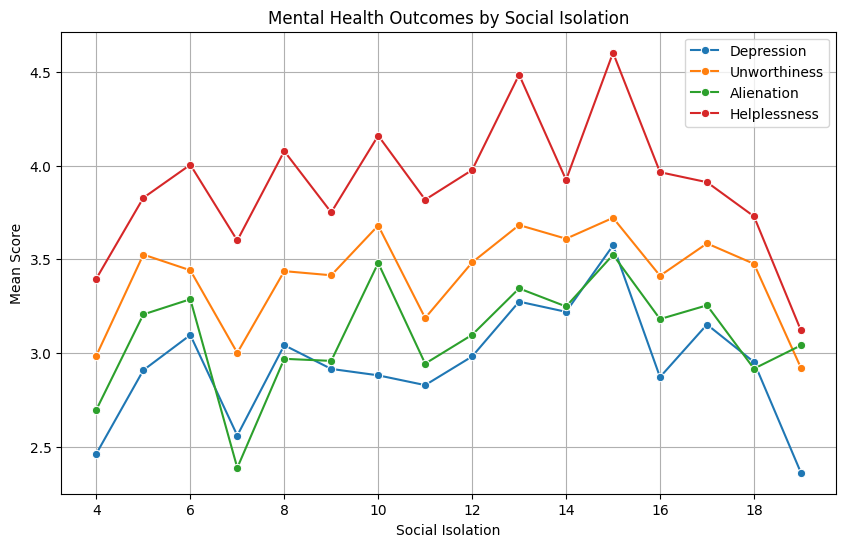

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. GROUP THEO SocialIsolation
# =========================
grouped = df_xgb.groupby("SocialIsolation")[[
    "Depression", "Unworthiness", "Alienation", "Helplessness"
]].mean().reset_index()

# =========================
# 2. VẼ BIỂU ĐỒ
# =========================
plt.figure(figsize=(10, 6))

sns.lineplot(data=grouped, x="SocialIsolation", y="Depression", marker="o", label="Depression")
sns.lineplot(data=grouped, x="SocialIsolation", y="Unworthiness", marker="o", label="Unworthiness")
sns.lineplot(data=grouped, x="SocialIsolation", y="Alienation", marker="o", label="Alienation")
sns.lineplot(data=grouped, x="SocialIsolation", y="Helplessness", marker="o", label="Helplessness")

plt.title("Mental Health Outcomes by Social Isolation")
plt.xlabel("Social Isolation")
plt.ylabel("Mean Score")

plt.legend()
plt.grid(True)
plt.show()

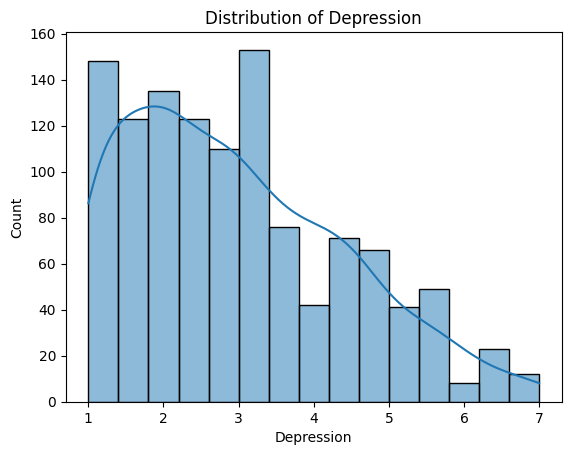

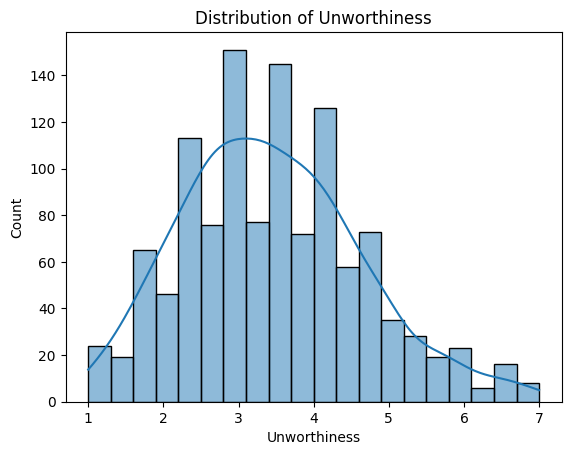

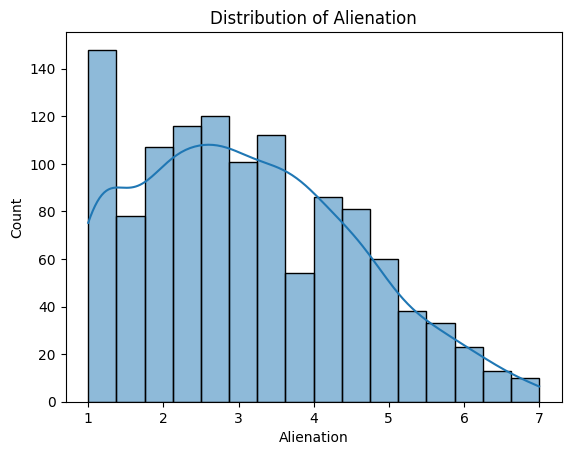

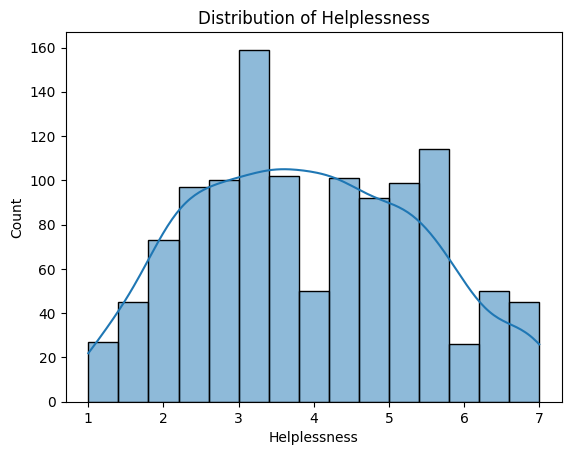

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ["Depression","Unworthiness","Alienation","Helplessness"]:
    plt.figure()
    sns.histplot(df_xgb[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

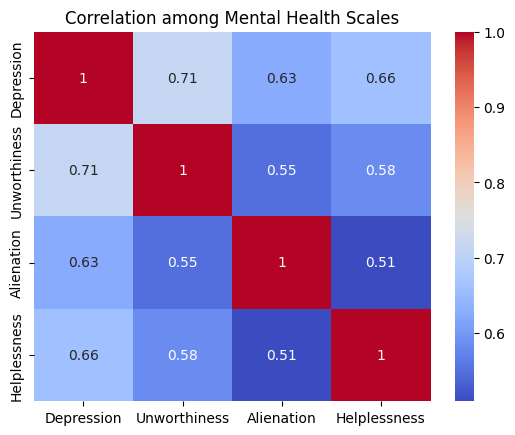

In [32]:
sns.heatmap(df_xgb[["Depression","Unworthiness","Alienation","Helplessness"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation among Mental Health Scales")
plt.show()

## Chạy model xgb

In [33]:
pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 4.5 MB/s eta 0:00:00


In [34]:
# CLEAN DATA TRƯỚC KHI MODEL
X = X.apply(pd.to_numeric, errors='coerce')
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

# sync lại df_xgb
df_xgb = df_xgb.loc[X.index].reset_index(drop=True)
X = X.reset_index(drop=True)

In [ ]:
# ============================================
# FULL PIPELINE: CLEAN + SPLIT + TUNE + TRAIN + SAVE
# ============================================

import numpy as np
import pandas as pd
import optuna
import joblib
import shap
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# =========================
# 1. SETUP
# =========================
outcomes = ["Depression", "Unworthiness", "Alienation", "Helplessness"]

X = df_xgb[predictors].copy()
y_dict = {col: df_xgb[col].copy() for col in outcomes}

RANDOM_STATE = 42
TEST_SIZE = 0.2
N_TRIALS = 250   # tăng lên nếu muốn

# =========================
# 2. CLEAN DATA (BẮT BUỘC)
# =========================
X = X.apply(pd.to_numeric, errors='coerce')
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna()

# sync lại df_xgb
df_xgb = df_xgb.loc[X.index].reset_index(drop=True)
X = X.reset_index(drop=True)

y_dict = {col: df_xgb[col] for col in outcomes}

# =========================
# 3. SPLIT (CHỈ 1 LẦN)
# =========================
X_train, X_test = train_test_split(
    X, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# =========================
# 4. METRIC FUNCTION
# =========================
def eval_metrics(y_true, y_pred):
    return {
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }

# =========================
# 5. OPTUNA OBJECTIVE
# =========================
def optimize_xgb(trial, X_train, y_train):
    params = {
        "objective": "reg:squarederror",
        "tree_method": "hist",
        "random_state": RANDOM_STATE,
        "n_jobs": -1,

        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "min_child_weight": trial.suggest_float("min_child_weight", 1, 10),

        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),

        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-2, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),

        "n_estimators": trial.suggest_int("n_estimators", 200, 800),
    }

    model = XGBRegressor(**params)

    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )

    return -scores.mean()

# =========================
# 6. TRAIN LOOP
# =========================
results = {}
models = {}

for outcome in outcomes:

    print(f"\n🔥 TRAINING: {outcome}")

    y = y_dict[outcome]

    # align y theo split
    y_train = y.loc[X_train.index]
    y_test  = y.loc[X_test.index]

    # ---- OPTUNA ----
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: optimize_xgb(trial, X_train, y_train),
                   n_trials=N_TRIALS)

    best_params = study.best_trial.params

    # ---- TRAIN FINAL MODEL ----
    model = XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        **best_params
    )

    model.fit(X_train, y_train)

    # ---- EVALUATE ----
    preds = model.predict(X_test)
    metrics = eval_metrics(y_test, preds)

    results[outcome] = metrics
    models[outcome] = model

    print("Best params:", best_params)
    print("Test:", metrics)

    # ---- SAVE MODEL ----
    joblib.dump(model, f"xgb_{outcome}.pkl")

# =========================
# 7. SUMMARY
# =========================
summary = pd.DataFrame(results).T
summary

[I 2026-04-02 06:16:52,948] A new study created in memory with name: no-name-a7719c37-89dc-40ac-8df9-896a86bfc7ce



🔥 TRAINING: Depression


[I 2026-04-02 06:16:59,420] Trial 0 finished with value: 1.1521490552597697 and parameters: {'learning_rate': 0.04854677597458545, 'max_depth': 2, 'min_child_weight': 9.522521796039683, 'subsample': 0.7835997410101364, 'colsample_bytree': 0.8710274095095167, 'gamma': 0.8422956703857132, 'reg_lambda': 1.5579202926370455, 'reg_alpha': 0.05047514217602511, 'n_estimators': 542}. Best is trial 0 with value: 1.1521490552597697.
[I 2026-04-02 06:17:00,008] Trial 1 finished with value: 1.1313783328472513 and parameters: {'learning_rate': 0.014664966318148957, 'max_depth': 3, 'min_child_weight': 8.303944170991517, 'subsample': 0.8876705112275274, 'colsample_bytree': 0.8824267966441411, 'gamma': 4.716026118791095, 'reg_lambda': 5.080119120264414, 'reg_alpha': 0.018476386994048456, 'n_estimators': 381}. Best is trial 1 with value: 1.1313783328472513.
[I 2026-04-02 06:17:00,722] Trial 2 finished with value: 1.1558779688258838 and parameters: {'learning_rate': 0.09060561637746858, 'max_depth': 5, '

Best params: {'learning_rate': 0.03665665503157354, 'max_depth': 2, 'min_child_weight': 8.939039962463214, 'subsample': 0.769925875401333, 'colsample_bytree': 0.8673964851055493, 'gamma': 0.18693899591671337, 'reg_lambda': 9.005311967788275, 'reg_alpha': 3.065532762438927, 'n_estimators': 248}
Test: {'RMSE': np.float64(1.3843908564709386), 'MAE': 1.1443650340629836, 'R2': 0.1104660652383398}

🔥 TRAINING: Unworthiness


[I 2026-04-02 06:19:16,678] Trial 0 finished with value: 0.8722173735113895 and parameters: {'learning_rate': 0.10228602297228256, 'max_depth': 3, 'min_child_weight': 2.2808341089234023, 'subsample': 0.727944243265772, 'colsample_bytree': 0.7772420100730556, 'gamma': 4.901772566016389, 'reg_lambda': 0.2898610736185115, 'reg_alpha': 0.4780688139964052, 'n_estimators': 606}. Best is trial 0 with value: 0.8722173735113895.
[I 2026-04-02 06:19:17,366] Trial 1 finished with value: 0.8759055180956515 and parameters: {'learning_rate': 0.04766616236169991, 'max_depth': 8, 'min_child_weight': 5.589096346960812, 'subsample': 0.6697632872887145, 'colsample_bytree': 0.8415717581990237, 'gamma': 4.612855225715647, 'reg_lambda': 0.012990221817907812, 'reg_alpha': 0.006805772326978941, 'n_estimators': 651}. Best is trial 0 with value: 0.8722173735113895.
[I 2026-04-02 06:19:18,452] Trial 2 finished with value: 0.9079774725213051 and parameters: {'learning_rate': 0.03617081394370259, 'max_depth': 8, '

...

[I 2026-04-02 06:22:03,658] Trial 0 finished with value: 1.0825778918828324 and parameters: {'learning_rate': 0.03694140797216073, 'max_depth': 3, 'min_child_weight': 7.144630798411523, 'subsample': 0.8174169208892608, 'colsample_bytree': 0.803026717655178, 'gamma': 3.729338513814588, 'reg_lambda': 0.02653404497162726, 'reg_alpha': 2.2130965284565267, 'n_estimators': 368}. Best is trial 0 with value: 1.0825778918828324.
[I 2026-04-02 06:22:05,073] Trial 1 finished with value: 1.098935151671177 and parameters: {'learning_rate': 0.02018182629450408, 'max_depth': 8, 'min_child_weight': 5.367445632894408, 'subsample': 0.7906769688322022, 'colsample_bytree': 0.7453076267492479, 'gamma': 1.2763765334834813, 'reg_lambda': 0.06193674143840929, 'reg_alpha': 0.5421074076049411, 'n_estimators': 698}. Best is trial 0 with value: 1.0825778918828324.
[I 2026-04-02 06:22:05,799] Trial 2 finished with value: 1.1257877032943076 and parameters: {'learning_rate': 0.13148376616337026, 'max_depth': 8, 'min

Best params: {'learning_rate': 0.014668941531907459, 'max_depth': 2, 'min_child_weight': 7.820486866676008, 'subsample': 0.6382681854639317, 'colsample_bytree': 0.6593636199214354, 'gamma': 0.3143620038198706, 'reg_lambda': 0.06704195282519308, 'reg_alpha': 0.059520067408775, 'n_estimators': 744}
Test: {'RMSE': np.float64(1.3589103778094538), 'MAE': 1.0852427949339654, 'R2': 0.1449601315611253}

🔥 TRAINING: Helplessness


[I 2026-04-02 06:26:04,868] Trial 0 finished with value: 1.2065915755879082 and parameters: {'learning_rate': 0.038837497752129316, 'max_depth': 5, 'min_child_weight': 4.476233385497457, 'subsample': 0.9212071500987588, 'colsample_bytree': 0.620607416405351, 'gamma': 0.2726996503994211, 'reg_lambda': 6.742662646394784, 'reg_alpha': 0.016872337100843595, 'n_estimators': 350}. Best is trial 0 with value: 1.2065915755879082.
[I 2026-04-02 06:26:05,433] Trial 1 finished with value: 1.2133811988334566 and parameters: {'learning_rate': 0.07087828506728691, 'max_depth': 4, 'min_child_weight': 7.3229929191003995, 'subsample': 0.6166289513785136, 'colsample_bytree': 0.8099445340853584, 'gamma': 2.872303050519673, 'reg_lambda': 0.116855727096617, 'reg_alpha': 0.015287407503794011, 'n_estimators': 400}. Best is trial 0 with value: 1.2065915755879082.
[I 2026-04-02 06:26:06,808] Trial 2 finished with value: 1.1775793614621555 and parameters: {'learning_rate': 0.010164839518723018, 'max_depth': 6, 

Best params: {'learning_rate': 0.016754870025767275, 'max_depth': 3, 'min_child_weight': 9.924836774850705, 'subsample': 0.7334106530179544, 'colsample_bytree': 0.6973306041439902, 'gamma': 2.9065769470214313, 'reg_lambda': 1.899224376607989, 'reg_alpha': 0.0017333996030524047, 'n_estimators': 369}
Test: {'RMSE': np.float64(1.46063347061123), 'MAE': 1.2092065268653933, 'R2': 0.08445662869187676}


,RMSE,MAE,R2
Depression,1.384391,1.144365,0.110466
Unworthiness,1.112965,0.905696,0.167993
Alienation,1.358910,1.085243,0.144960
Helplessness,1.460633,1.209207,0.084457


In [ ]:
from google.colab import files

for outcome in outcomes:
    files.download(f"xgb_model_{outcome}.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
from google.colab import files
uploaded = files.upload()

Saving xgb_model_Alienation.pkl to xgb_model_Alienation.pkl
Saving xgb_model_Helplessness.pkl to xgb_model_Helplessness.pkl
Saving xgb_model_Unworthiness.pkl to xgb_model_Unworthiness.pkl
Saving xgb_model_Depression.pkl to xgb_model_Depression.pkl


In [39]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results = {}

for outcome in ["Depression", "Unworthiness", "Alienation", "Helplessness"]:

    model = models[outcome]

    y = df_xgb[outcome]
    y_test = y.loc[X_test.index]

    preds = model.predict(X_test)

    results[outcome] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "MAE": mean_absolute_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    }

summary = pd.DataFrame(results).T.round(4)
summary

,RMSE,MAE,R2
Depression,1.4075,1.1378,0.0805
Unworthiness,1.1064,0.8928,0.1778
Alienation,1.3566,1.0759,0.1478
Helplessness,1.4479,1.2086,0.1003


## SHAP VALUE

In [41]:
import shap

# chọn data dùng để giải thích (thường dùng train)
X_shap = X_train.copy()

shap_values_dict = {}

for outcome in outcomes:
    model = models[outcome]

    explainer = shap.Explainer(model)
    shap_values = explainer(X_shap)

    shap_values_dict[outcome] = shap_values

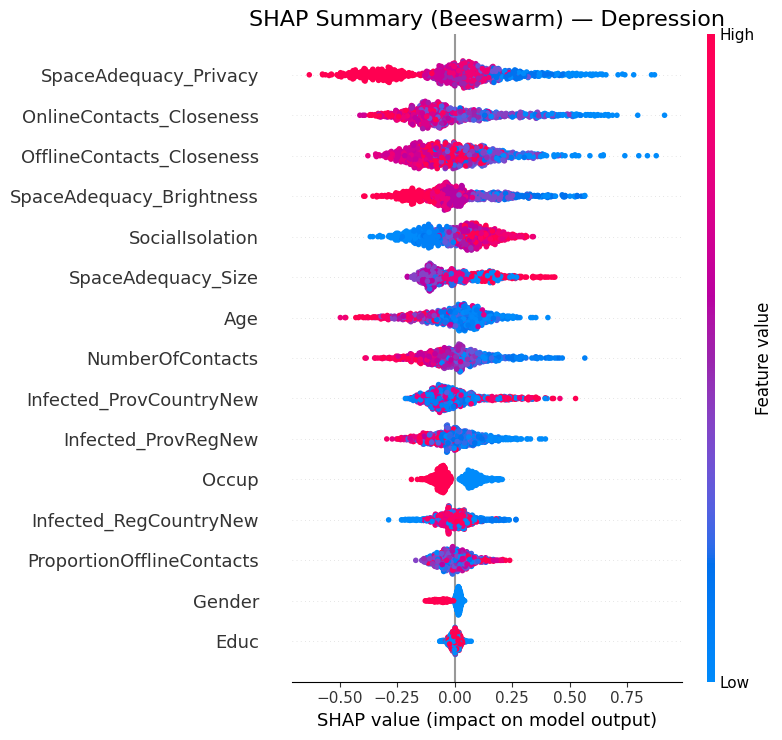

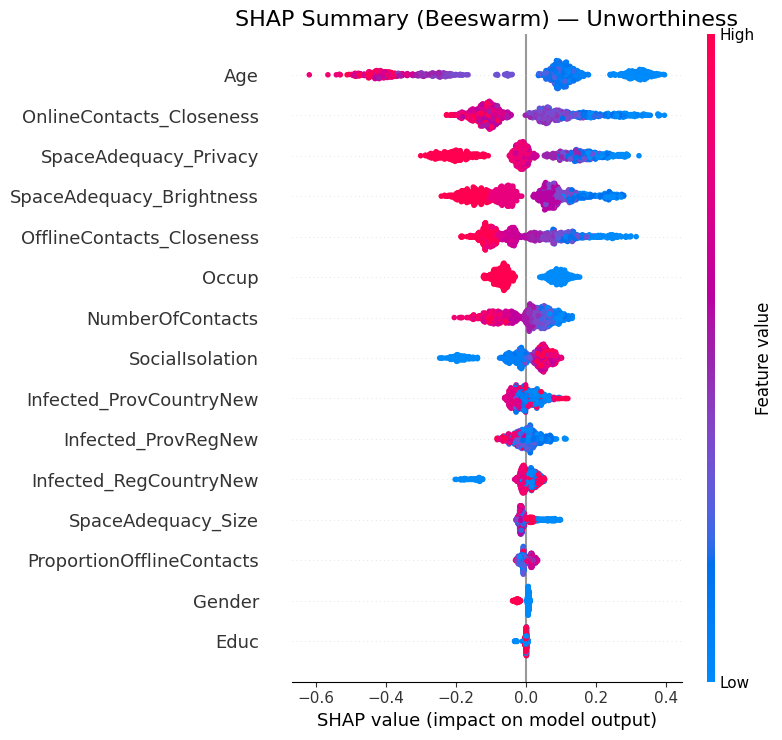

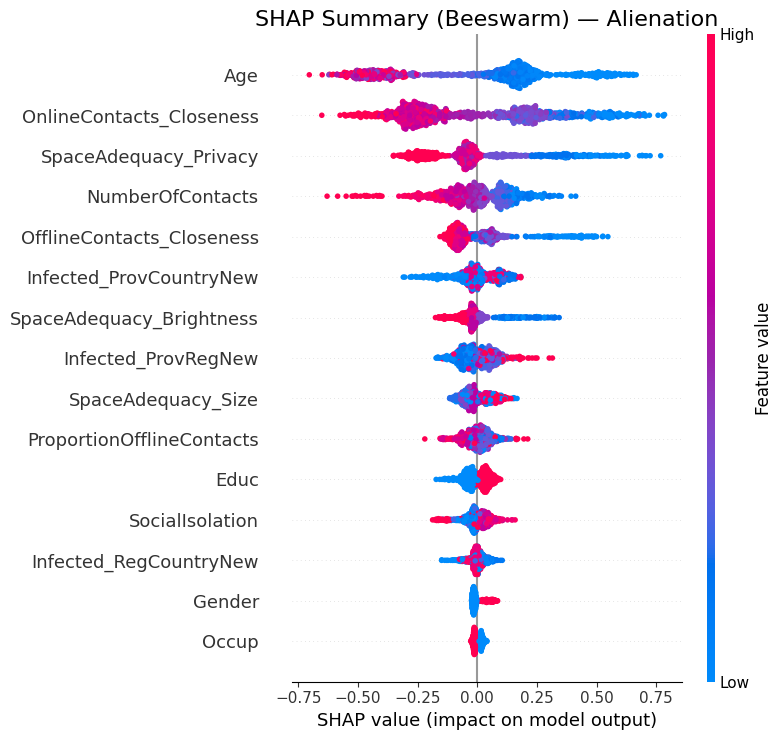

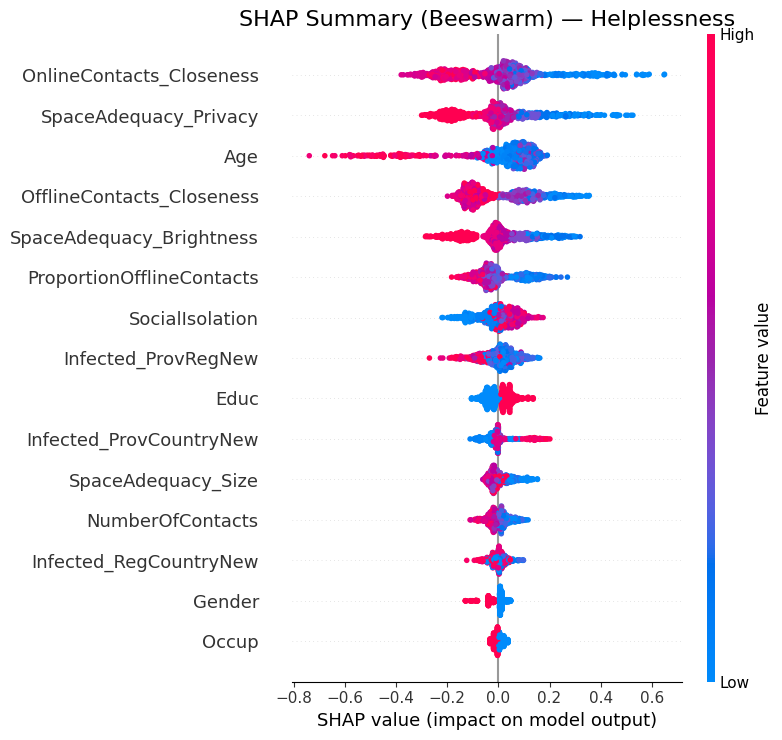

In [43]:
for outcome in outcomes:
    shap.plots.beeswarm(
        shap_values_dict[outcome],
        max_display=15,
        show=False
    )

    plt.title(f"SHAP Summary (Beeswarm) — {outcome}", fontsize=16)
    plt.xlabel("SHAP value (impact on model output)")

    plt.tight_layout()
    plt.show()